# 05 · CNN: 같은 작은 계산을 이미지 전체에 쓰기

**이번 질문:** MLP는 화소마다 다른 가중치를 둡니다. 이미지의 어느 위치에 있든 같은 모양(획)을 찾으려면 수식이 어떻게 바뀔까요?

03번의 MLP는 784개 화소 각각에 가중치를 따로 두었습니다. 7이 한 칸 옆으로 옮겨 쓰이면 전혀 다른 화소가 켜지므로, 같은 모양을 자리마다 새로 배워야 합니다.
이번에는 작은 창(3×3) 하나의 가중치를 이미지의 **모든 자리에서 같이 쓰는** 합성곱을 만듭니다.
반복문 → 패치 행렬곱 → 겹친 자리를 더하는 역전파 → 풀링 → 작은 분류기까지 한 흐름으로 갑니다.

- 준비물: [00](../00_기초/00_math_to_numpy.ipynb)의 내적·행렬곱, [03](../00_기초/03_perceptron_to_mlp.ipynb)의 forward·backward·캐시, [02](../00_기초/02_probability_and_losses.ipynb)의 softmax CE, [04](../00_기초/04_optimizers.ipynb)의 Adam.
- 도착점: 합성곱·풀링의 forward와 backward를 직접 쓰고 수치미분으로 검산한 뒤, 작은 숫자 도안 분류기를 학습시킵니다.
- 다음 연결: [06 RNN](06_rnn.ipynb)은 같은 가중치를 위치가 아니라 **시간**에 공유합니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 합성곱의 출력 한 칸은 **입력의 작은 창과 커널의 내적**입니다. 커널 하나를 모든 자리에 옮겨 쓰므로 파라미터는 창 크기만큼만 있습니다. 코드로는 `np.sum(Xp[..., i:i+kh, j:j+kw] * K)`.
2. 창을 행으로 펼쳐 쌓은 패치 행렬 $P$로 쓰면 합성곱은 행렬곱 하나입니다. `rows = P @ K.reshape(F, -1).T + b`. backward는 03번의 affine backward와 같은 세 식이고, **겹친 자리로 돌아오는 기울기는 더합니다**(`+=`).
3. 풀링은 2×2 구역마다 값 하나만 남겨 크기를 줄입니다. 평균은 기울기를 넷으로 나누어 돌려주고, 최대는 최댓값 자리 하나로 보냅니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/cnn_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)          # 현재 폴더부터 위로 올라가며
                    if (p / "src/utils/plotting.py").is_file())            # src/utils/plotting.py가 있는 첫 폴더를 고릅니다
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(3절: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 데이터 로더, 이 노트북의 그림 함수(src/utils/cnn_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_examples
from src.utils.cnn_plots import (
    plot_curves, plot_images, plot_conv_scene, plot_conv_on_image, plot_patch_matrix,
    plot_overlap_count, plot_pooling, plot_cnn_blocks,
)

# 3) 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· CNN 준비 완료")

NumPy 2.3.5 · CNN 준비 완료


### 📎 이 노트북의 예시: 숫자 격자, MNIST 7, 8×8 숫자 도안

- **숫자 격자.** 5×5 입력과 3×3 커널처럼 손으로 곱해 더할 수 있는 작은 정수 격자로 합성곱·패치·풀링을 먼저 봅니다.
- **MNIST 7.** 00번부터 쓴 고정 예시 10장 중 7입니다. 같은 계산을 28×28 이미지에 적용하면 무엇이 보이는지 확인합니다. 학습에는 쓰지 않습니다.
- **8×8 숫자 도안.** 5절에서 본문 코드로 만드는 작은 데이터입니다. 0–9 도안을 위치와 잡음을 바꿔 그리며, 외부 다운로드 없이 몇 초 안에 학습이 끝납니다.

> **용어**
>
> - **텐서 모양 $(N, C, H, W)$**: 이미지 배치를 (이미지 수, 채널 수, 높이, 너비)로 쌓은 4차원 배열. 흑백이면 $C=1$, 컬러면 $C=3$. 코드에서는 `X.shape == (N, C, H, W)`.
> - **채널(channel)**: 같은 위치를 설명하는 값의 층. 입력의 채널은 색이고, 합성곱 출력의 채널은 "커널 하나가 만든 지도" 하나입니다.

아래 셀은 실행만 하고 넘어가도 됩니다. 두 번에 나누어 공부해도 됩니다. 먼저 1–4절의 창·패치·미분을 확인하고, 다음에 5–7절의 학습과 연습을 진행하세요.

In [2]:
mnist_examples, mnist_labels = load_examples(download=True)     # (10, 28, 28) 예시 이미지 10장, (10,) 정답 숫자
mnist_7 = mnist_examples[7]                                      # (28, 28): 예시 7 한 장. 값은 0–1 잉크
grid_X = np.array([[1., 2., 0., 1., 0.],
                   [0., 1., 2., 0., 1.],
                   [1., 0., 1., 2., 0.],
                   [2., 1., 0., 1., 1.],
                   [0., 2., 1., 0., 2.]])                        # (5, 5): 손계산용 입력
grid_K = np.array([[1., 0., -1.],
                   [1., 0., -1.],
                   [1., 0., -1.]])                               # (3, 3): 커널. 창의 왼쪽 열 − 오른쪽 열
print("MNIST 예시", mnist_examples.shape, "· 7의 잉크 합", mnist_7.sum().round(1), "· 격자", grid_X.shape, grid_K.shape)

MNIST 예시 (10, 28, 28) · 7의 잉크 합 49.5 · 격자 (5, 5) (3, 3)


## 🔑 1. 합성곱: 작은 창 하나의 내적을 이미지 전체에서 반복합니다

**이 절에서 가져갈 것:** 출력의 한 칸은 "입력에서 창을 하나 오려 커널과 같은 자리끼리 곱해 더한 값"입니다. 창을 한 칸씩 옮기며 같은 커널을 다시 쓰므로, 출력 칸이 아무리 많아도 파라미터는 커널 하나뿐입니다.

5×5 격자 위에 3×3 창을 댑니다. 창 안의 아홉 칸과 커널의 아홉 칸을 같은 자리끼리 곱해 더하면 숫자 하나가 나옵니다.
창을 오른쪽으로 한 칸 옮겨 같은 일을 하고, 줄이 끝나면 아래 줄로 내려갑니다. 5×5에 3×3 창이 들어갈 자리는 가로 3, 세로 3이므로 출력은 3×3입니다.

> **용어**
>
> - **합성곱(convolution)**: 작은 창을 옮겨 가며 창과 커널의 내적을 모든 자리에서 계산하는 연산. 코드에서는 `np.sum(Xp[..., i:i+kh, j:j+kw] * K)`를 자리 $(i, j)$마다 반복합니다.
> - **커널(kernel)·필터(filter)** $K$: 창 크기의 가중치. 03번의 $W$처럼 학습하는 값이지만 모든 자리에서 **같은 값**을 씁니다. 커널이 $F$개면 출력 채널도 $F$개입니다.
> - **stride** $s$: 창을 한 번에 옮기는 칸 수. **padding** $p$: 가장자리에 두르는 0의 두께. 창이 가장자리 칸도 가운데에 둘 수 있게 합니다.
> - **특성 맵(feature map)**: 출력 $Y$의 채널 하나. "이 커널이 어느 자리에 얼마나 맞았나"를 적은 지도입니다.

입력 $X$의 shape를 $(N,C,H,W)$, 커널 $K$를 $(F,C,k_h,k_w)$로 정합니다. $N$은 이미지 수, $C$는 입력 채널, $F$는 출력 채널입니다. 한 출력은 작은 입력 영역과 커널의 내적입니다.

$$Y_{n,f,i,j}=b_f+\sum_{c=0}^{C-1}\sum_{u=0}^{k_h-1}\sum_{v=0}^{k_w-1}
X^{pad}_{n,c,is+u,js+v}K_{f,c,u,v}.$$

이미지 $n$의 출력 채널 $f$에서 $(i,j)$ 칸은, 왼쪽 위가 $(is, js)$인 창의 값과 커널 $f$를 채널·세로·가로 모두에서 곱해 더한 것에 편향 $b_f$를 더한 값입니다.

$s$는 창을 한 번에 몇 픽셀 옮길지 정하는 stride, $p$는 사방에 더한 0의 두께입니다. $\lfloor a\rfloor$는 $a$ 이하의 가장 큰 정수입니다. 끝에 창 전체가 들어가지 않는 위치는 제외하므로 내림을 씁니다.
$$H_o=\left\lfloor\frac{H+2p-k_h}{s}\right\rfloor+1,\quad
W_o=\left\lfloor\frac{W+2p-k_w}{s}\right\rfloor+1.$$

📎 딥러닝에서 convolution이라고 부르는 위 연산은 커널을 뒤집지 않는 **cross-correlation**입니다. 여기서도 그 관례를 씁니다. 수학의 convolution과 부호·뒤집기 관례를 섞지 않습니다.

아래는 5×5 격자에서 창을 두 자리에 댄 장면입니다. 계산은 NumPy 반복문으로 직접 합니다.

> **코드**
>
> - `grid_X[i:i + 3, j:j + 3]`: 2차원 슬라이스. 행 i부터 3줄, 열 j부터 3칸을 오려 낸 `(3, 3)` 창입니다. `* grid_K`는 같은 자리끼리 곱하고 `np.sum`이 아홉 개를 더합니다.
> - `edge_K.T`: 전치. 가로 경계 커널을 돌리면 세로 경계 커널이 됩니다.
> - `np.unravel_index(np.argmax(a), a.shape)`: 펼친 위치 번호를 (행, 열)로 되돌립니다. 가장 큰 값이 어느 칸인지 찾습니다.
> - `np.pad(X, ((0, 0), (0, 0), (p, p), (p, p)))`: 축마다 (앞, 뒤)에 두를 0의 두께. 배치·채널 축은 0, 세로·가로에만 p칸.
> - `grid_X[None, None]`: 앞에 길이 1인 축 두 개를 붙여 `(5, 5)`를 `(1, 1, 5, 5)` = (N, C, H, W)로 만듭니다.

In [3]:
grid_Y = np.zeros((3, 3))                                            # (3, 3): 출력. 창이 들어갈 자리 3 × 3
for i in range(3):                                                   # 자리 (i, j)마다
    for j in range(3):
        grid_Y[i, j] = np.sum(grid_X[i:i + 3, j:j + 3] * grid_K)    # 창 ⊙ 커널을 모두 더함
grid_positions = [(0, 0), (1, 2)]                                    # 그림에서 볼 두 자리
print("출력 (3, 3):\n", grid_Y)
print("(0, 0) 칸의 창:\n", grid_X[0:3, 0:3], "\n→ 창 ⊙ 커널의 합 =", grid_Y[0, 0])

출력 (3, 3):
 [[-1.  0.  2.]
 [ 0. -1.  1.]
 [ 1.  0. -1.]]
(0, 0) 칸의 창:
 [[1. 2. 0.]
 [0. 1. 2.]
 [1. 0. 1.]] 
→ 창 ⊙ 커널의 합 = -1.0


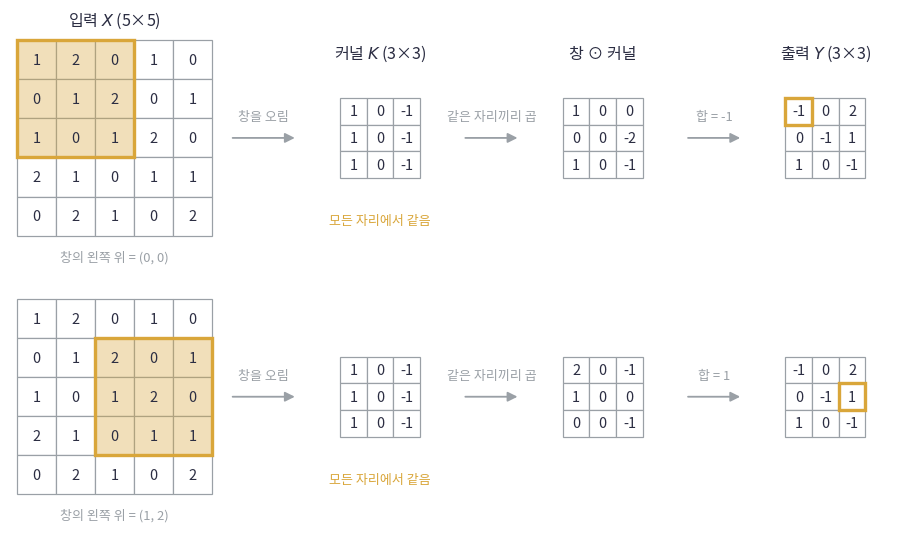

In [4]:
plot_conv_scene(grid_X, grid_K, grid_Y, grid_positions)

🔍 **확인** · 위 행은 창을 왼쪽 위 (0, 0)에 댄 장면, 아래 행은 (1, 2)에 댄 장면입니다. 가운데 커널은 두 행에서 **같은 숫자**입니다. 달라지는 것은 창 안의 입력뿐이고, 곱해 더한 값이 출력의 해당 칸에 들어갑니다.
이 커널은 창의 왼쪽 열에서 오른쪽 열을 빼므로 "왼쪽이 크고 오른쪽이 작은 자리"에서 양수가 됩니다. 출력 3×3의 부호를 창 안의 숫자와 맞춰 보세요.

### 🔍 같은 계산을 7 이미지에서 보면

28×28 이미지에 3×3 커널을 대면 창이 들어갈 자리는 26×26입니다. 커널 값 아홉 개가 자리 676개를 모두 채웁니다.

In [5]:
edge_K = np.array([[1., 1., 1.], [0., 0., 0.], [-1., -1., -1.]])      # (3, 3): 위 행 − 아래 행. 가로획의 아래 경계에서 양수
mnist_feature = np.zeros((26, 26))                                    # (26, 26): 28 − 3 + 1 = 26 자리
mnist_feature_v = np.zeros((26, 26))
for i in range(26):
    for j in range(26):
        mnist_feature[i, j] = np.sum(mnist_7[i:i + 3, j:j + 3] * edge_K)       # 가로 경계 커널
        mnist_feature_v[i, j] = np.sum(mnist_7[i:i + 3, j:j + 3] * edge_K.T)   # 같은 커널을 돌린 세로 경계 커널
mnist_peak = np.unravel_index(np.argmax(mnist_feature), mnist_feature.shape)   # 가로 커널이 가장 크게 반응한 칸 (행, 열)
print("특성 맵", mnist_feature.shape, "· 가장 큰 반응", mnist_feature.max().round(2), "at", mnist_peak)

특성 맵 (26, 26) · 가장 큰 반응 2.84 at (np.int64(10), np.int64(8))


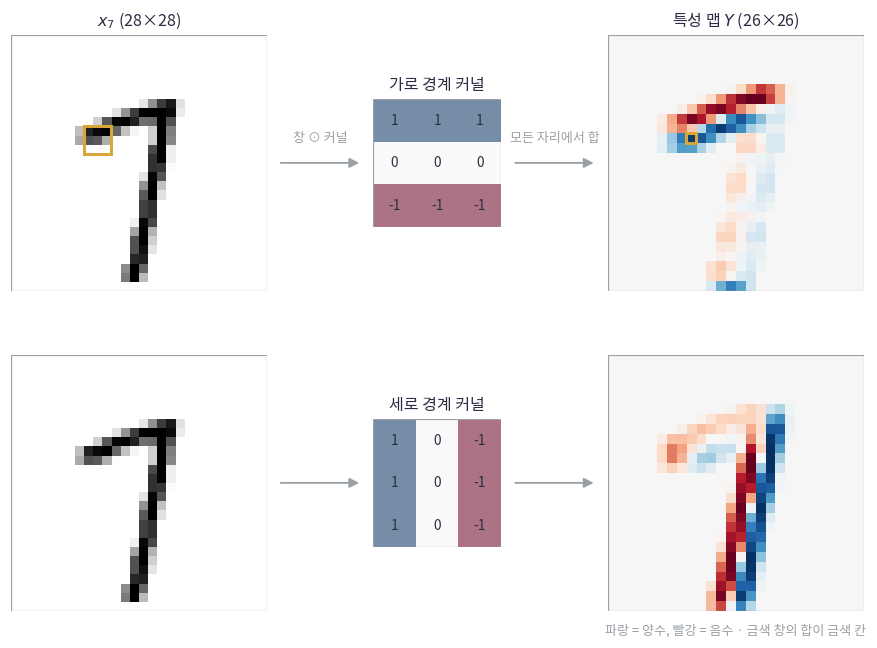

In [6]:
plot_conv_on_image(mnist_7, [edge_K, edge_K.T], ["가로 경계 커널", "세로 경계 커널"], [mnist_feature, mnist_feature_v], mnist_peak)

🔍 **확인** · 가로 경계 커널은 잉크가 위에 있고 아래가 비는 자리, 즉 7의 윗획 **아래쪽 경계**에서 파랑(양수)이고 위쪽 경계에서 빨강(음수)입니다. 금색 창이 가장 크게 반응한 자리이고, 그 합이 오른쪽 금색 칸입니다.
같은 커널을 돌린 세로 경계 커널은 내려오는 획의 양옆을 찾습니다. 03번의 MLP였다면 이 지도 한 장을 만드는 데 자리마다 다른 가중치가 필요했을 것입니다.

아래는 이 반복문을 배치·채널·stride·padding까지 일반화한 구현입니다. 느리지만 수식을 한 줄씩 옮긴 기준 구현이라 2절의 빠른 구현을 검산하는 잣대로 씁니다.

In [7]:
def conv_loops(X, K, b, stride=1, padding=0):
    """합성곱을 수식 그대로 7중 반복문으로 (느린 기준 구현). Y[n, f, i, j] = b[f] + Σ_c Σ_u Σ_v Xpad[n, c, is+u, js+v] K[f, c, u, v].
    X: (N, C, H, W), K: (F, C, kh, kw), b: (F,) → Y: (N, F, oh, ow)."""
    N, C, H, W = X.shape
    F, Ck, kh, kw = K.shape
    assert C == Ck, "커널의 입력 채널 수는 X의 채널 수와 같아야 합니다"
    assert stride >= 1, "stride는 1 이상이어야 합니다"
    assert padding >= 0, "padding은 0 이상이어야 합니다"
    Xp = np.pad(X, ((0, 0), (0, 0), (padding, padding), (padding, padding)))   # 세로·가로에만 0을 두름
    oh = (H + 2 * padding - kh) // stride + 1               # 출력 높이 (위 공식, 내림)
    ow = (W + 2 * padding - kw) // stride + 1
    Y = np.zeros((N, F, oh, ow))
    for n in range(N):                                      # 이미지마다
        for f in range(F):                                  # 출력 채널(커널)마다
            for i in range(oh):                             # 출력 자리 (i, j)마다
                for j in range(ow):
                    value = b[f]                            # 편향에서 시작해
                    for c in range(C):                      # 채널·세로·가로 축의 합 (수식의 Σ 세 개)
                        for u in range(kh):
                            for v in range(kw):
                                value += Xp[n, c, i * stride + u, j * stride + v] * K[f, c, u, v]
                    Y[n, f, i, j] = value
    return Y

In [8]:
# 쓰는 것: grid_X, grid_K, mnist_7 (📎 데이터 셀) · grid_Y (격자 셀) · edge_K, mnist_feature (7 특성 맵 셀)
small_X = np.arange(1., 10.).reshape(1, 1, 3, 3)          # (1, 1, 3, 3): 1…9
small_K = np.array([[[[1., 0.], [0., -1.]]]])              # (1, 1, 2, 2): 왼쪽 위 − 오른쪽 아래
small_Y = conv_loops(small_X, small_K, np.zeros(1))        # (1, 1, 2, 2)
np.testing.assert_allclose(small_Y, -4.)                   # 검산: 네 자리 모두 (대각선 차이) = −4
print("출력 shape:", small_Y.shape, "· 첫 패치 내적:", small_Y[0, 0, 0, 0])
np.testing.assert_allclose(conv_loops(grid_X[None, None], grid_K[None, None], np.zeros(1))[0, 0], grid_Y)          # 검산: 위 격자 그림과 같은 값
np.testing.assert_allclose(conv_loops(mnist_7[None, None], edge_K[None, None], np.zeros(1))[0, 0], mnist_feature)   # 검산: 위 7 특성 맵과 같은 값

출력 shape: (1, 1, 2, 2) · 첫 패치 내적: -4.0


🔍 **확인** · 3×3 입력 `1…9`에 커널 $\begin{bmatrix}1&0\\0&-1\end{bmatrix}$을 대면 네 위치의 출력이 모두 −4입니다. 이 입력의 대각선 차이가 어디서나 같기 때문이고, CNN이 언제나 같은 값을 내는 것은 아닙니다. 커널 값을 바꾼 뒤 다시 계산해 보세요.
격자 그림과 7의 특성 맵도 `conv_loops`가 같은 값을 냅니다.

같은 출력 크기의 완전 연결 층은 $(CHW+1)FH_oW_o$개 파라미터가 필요합니다. 지역 연결만 적용하면 $(Ck_hk_w+1)FH_oW_o$개, **공유까지 적용하면 $(Ck_hk_w+1)F$개**입니다. 공유는 서로 다른 위치가 같은 검출 규칙을 쓴다는 가정입니다.

In [9]:
C, H, W, F, kh, kw, oh, ow = 1, 8, 8, 6, 3, 3, 6, 6      # 5절 모델의 크기: 8×8 입력, 3×3 커널 6개, 출력 6×6
print("완전 연결:", (C * H * W + 1) * F * oh * ow)         # 출력 칸마다 입력 전체 + 편향
print("지역 연결만:", (C * kh * kw + 1) * F * oh * ow)     # 출력 칸마다 창 크기 + 편향
print("지역 연결 + 공유:", (C * kh * kw + 1) * F)          # 커널마다 하나

완전 연결: 14040
지역 연결만: 2160
지역 연결 + 공유: 60


## 🔑 2. 패치 행렬: 반복문을 행렬곱 하나로 옮깁니다

**이 절에서 가져갈 것:** 창 하나를 한 행으로 펼쳐 모든 자리의 창을 쌓으면 패치 행렬 $P$가 되고, 합성곱은 $Y_{rows}=PK_{flat}^\top+b$ 행렬곱 하나입니다. 새 수식이 아니라 1절의 같은 합을 행으로 묶은 것입니다.

1절의 반복문은 자리 $(i,j)$마다 아홉 개를 곱해 더했습니다. 00번에서 이미지 10장을 행으로 쌓아 `X @ w`로 점수 10개를 한 번에 냈듯이, 창 9개를 행으로 쌓으면 출력 9개가 행렬곱 한 번에 나옵니다.

> **용어**
>
> - **패치(patch)**: 창 하나를 오려 낸 $(C, k_h, k_w)$ 조각. 펼치면 길이 $Ck_hk_w$의 행 하나입니다.
> - **패치 행렬** $P$: 모든 자리의 패치를 행으로 쌓은 $(NH_oW_o)\times(Ck_hk_w)$ 행렬. 코드에서는 `patches.reshape(N * oh * ow, -1)`. 라이브러리에서는 im2col이라고 부릅니다.

각 위치의 패치를 한 행에 펼쳐 $P\in\mathbb R^{(NH_oW_o)\times(Ck_hk_w)}$로 모읍니다. 커널을 행별로 펼친 $K_{flat}\in\mathbb R^{F\times(Ck_hk_w)}$에 대해
$$Y_{rows}=PK_{flat}^T+b.$$

$P$의 행 하나와 $K_{flat}$의 행 하나의 내적이 1절의 출력 한 칸입니다. 패치 내부 축 순서 `(채널, 세로, 가로)`와 커널의 펼침 순서가 같아야 합니다. `transpose(0,3,1,2)`는 `(N,Ho,Wo,F)`를 `(N,F,Ho,Wo)`로 되돌립니다.

📎 패치를 복사하는 구현이어서 메모리를 더 씁니다. 실제 라이브러리의 빠른 커널 구현까지 다루는 것은 이 실습의 범위 밖입니다.

아래는 1절의 5×5 격자에서 창 9개를 행으로 쌓은 $P$입니다. `sliding_window_view`는 창을 모두 잘라 `(3, 3, 3, 3)`으로 돌려주고, 앞 두 축이 자리, 뒤 두 축이 창 안의 칸입니다.

> **코드**
>
> - `from numpy.lib.stride_tricks import sliding_window_view`: NumPy 안쪽 모듈에서 함수 하나를 가져옵니다. 셀 안에서 import해도 됩니다.
> - `patches[:, i, j] = Xp[:, :, i*s:i*s+kh, j*s:j*s+kw]`: 자리 (i, j)의 창 `(N, C, kh, kw)`를 패치 배열의 그 자리에 통째로 넣습니다.
> - `patches.reshape(N * oh * ow, -1)`: 앞 세 축(이미지, 자리)을 행 하나로, 뒤 세 축(채널, 세로, 가로)을 열 하나로 폅니다. `-1`은 "나머지를 알아서"입니다.
> - `K.reshape(F, -1).T`: 커널 F개를 각각 한 행으로 편 뒤 전치해 `(C·kh·kw, F)`. `P @` 뒤에 오는 행렬입니다.

In [10]:
# 쓰는 것: grid_X, grid_K (📎 데이터 셀) · grid_Y (1절 격자 셀)
from numpy.lib.stride_tricks import sliding_window_view
patch_P = sliding_window_view(grid_X, (3, 3)).reshape(9, 9)     # (9, 9): 행 = 자리 (i, j), 열 = 창 안의 9칸
patch_k = grid_K.reshape(-1)                                     # (9,): 커널을 같은 순서로 펼침
patch_rows = patch_P @ patch_k                                   # (9,): 자리마다 출력 하나
np.testing.assert_allclose(patch_rows.reshape(3, 3), grid_Y)     # 검산: 1절 반복문과 같은 값
print("P", patch_P.shape, "· k", patch_k.shape, "\n첫 행 (0,0)의 창", patch_P[0], "· 첫 행 @ k =", patch_rows[0])

P (9, 9) · k (9,) 
첫 행 (0,0)의 창 [1. 2. 0. 0. 1. 2. 1. 0. 1.] · 첫 행 @ k = -1.0


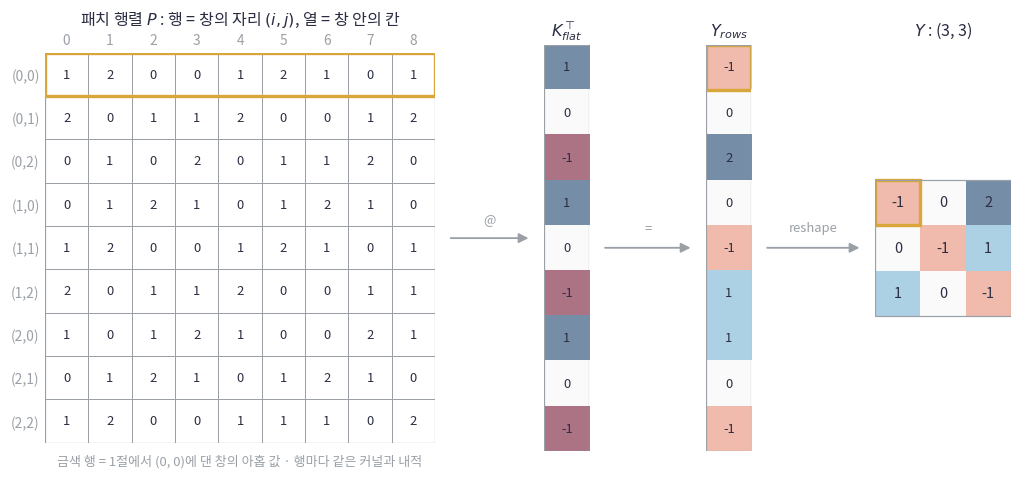

In [11]:
plot_patch_matrix(patch_P, patch_k, patch_rows, grid_Y, highlight_row=0)

🔍 **확인** · $P$의 행 하나가 1절의 창 하나입니다. 금색 첫 행이 (0, 0)에 댄 창의 아홉 값이고, 펼친 커널과의 내적이 $Y_{rows}$의 첫 칸, 접으면 $Y$의 (0, 0)입니다.
행마다 같은 커널과 내적하므로 행렬곱 한 번에 아홉 칸이 나옵니다. 커널이 $F$개면 $K_{flat}^\top$의 열이 $F$개가 되어 $Y_{rows}$는 $(9, F)$가 됩니다.
아래 구현은 배치·채널을 포함해 패치를 쌓고, backward에 쓰려고 $P$를 캐시에 남깁니다.

In [12]:
def conv_forward(X, K, b, stride=1, padding=0):
    """패치 행렬로 합성곱: 모든 창을 행으로 쌓은 P에 대해 Y_rows = P K_flatᵀ + b, 그다음 (N, F, oh, ow)로 접습니다.
    X: (N, C, H, W), K: (F, C, kh, kw), b: (F,) → (Y: (N, F, oh, ow), cache: backward용 (X.shape, K, P, stride, padding))."""
    N, C, H, W = X.shape
    F, Ck, kh, kw = K.shape
    assert C == Ck, "커널의 입력 채널 수는 X의 채널 수와 같아야 합니다"
    assert stride >= 1, "stride는 1 이상이어야 합니다"
    assert padding >= 0, "padding은 0 이상이어야 합니다"
    oh = (H + 2 * padding - kh) // stride + 1               # 출력 크기 (1절 공식)
    ow = (W + 2 * padding - kw) // stride + 1
    assert oh > 0, "커널이 입력보다 크면 출력 높이가 0이 됩니다"
    assert ow > 0, "커널이 입력보다 크면 출력 너비가 0이 됩니다"
    Xp = np.pad(X, ((0, 0), (0, 0), (padding, padding), (padding, padding)))
    patches = np.empty((N, oh, ow, C, kh, kw))              # 자리마다 창 하나 (C, kh, kw)
    for i in range(oh):
        for j in range(ow):
            patches[:, i, j] = Xp[:, :, i * stride:i * stride + kh, j * stride:j * stride + kw]   # 모든 이미지의 (i, j) 창
    P = patches.reshape(N * oh * ow, -1)                    # (N·oh·ow, C·kh·kw): 패치 행렬
    rows = P @ K.reshape(F, -1).T + b                       # (N·oh·ow, F): 행렬곱 한 번 + 편향
    Y = rows.reshape(N, oh, ow, F).transpose(0, 3, 1, 2)    # (N, F, oh, ow): 채널 축을 앞으로
    cache = (X.shape, K, P, stride, padding)
    return Y, cache

In [13]:
# 쓰는 것: conv_loops (1절) · grid_X, grid_K (📎 데이터 셀) · grid_Y (1절) · patch_P (2절 패치 셀)
rng = np.random.default_rng(5)                              # 이 노트북의 검산용 난수 생성기. 4·5·6절도 이어 씁니다
check_X = rng.normal(size=(2, 2, 4, 5))                     # (N, C, H, W) = (2, 2, 4, 5): 이미지 2장, 채널 2
check_K = rng.normal(size=(3, 2, 2, 3))                     # (F, C, kh, kw) = (3, 2, 2, 3): 2×3 커널 3개
check_b = rng.normal(size=3)                                # (3,)
for stride, padding in [(1, 0), (2, 1)]:                    # 두 설정에서 빠른 구현 = 반복문 구현
    fast, _ = conv_forward(check_X, check_K, check_b, stride, padding)
    slow = conv_loops(check_X, check_K, check_b, stride, padding)
    np.testing.assert_allclose(fast, slow, atol=1e-12)      # 검산: 패치 행렬곱 = 7중 반복문
    print(f"stride={stride}, padding={padding}: {fast.shape}, 최대 오차={np.max(np.abs(fast-slow)):.2e}")
grid_fast, grid_cache = conv_forward(grid_X[None, None], grid_K[None, None], np.zeros(1))
np.testing.assert_allclose(grid_fast[0, 0], grid_Y)               # 검산: 위 격자와 같은 값
np.testing.assert_allclose(grid_cache[2], patch_P)                # 검산: 캐시의 P가 위 그림의 패치 행렬

stride=1, padding=0: (2, 3, 3, 3), 최대 오차=1.78e-15
stride=2, padding=1: (2, 3, 3, 3), 최대 오차=8.88e-16


🔍 **확인** · stride·padding 두 설정에서 반복문 구현과 패치 행렬곱 구현의 최대 차이가 $10^{-12}$ 아래입니다. 캐시의 $P$는 위 그림의 패치 행렬과 같습니다.

## 🔑 3. backward: 공유한 커널로 돌아오는 기울기는 더합니다

**이 절에서 가져갈 것:** $Y_{rows}=PK_{flat}^\top+b$는 03번의 affine 층이므로 backward도 같은 세 식입니다. 한 가지가 추가됩니다. 한 입력 칸이 여러 창에 들어갔으면, 그 창들에서 돌아온 기울기를 **같은 칸에 더합니다**(`+=`).

3×3 입력에 2×2 창을 대면 자리는 네 곳이고, 가운데 칸은 네 창 모두에 들어갑니다. 출력 네 칸의 손실 기울기가 각각 자기 창으로 돌아오면, 가운데 칸은 네 몫을 다 받아야 합니다.

> **용어** · **상류 기울기(upstream gradient)** $G=\partial L/\partial Y_{rows}$: 손실에서 이 층의 출력까지 이미 계산된 기울기. 03번의 $D_\ell$과 같은 역할입니다.

$G=\partial L/\partial Y_{rows}$라 두면 01의 affine backward가 그대로 나옵니다.
$$dK_{flat}=G^TP,\qquad db=\sum_{rows}G,\qquad dP=GK_{flat}.$$

$dK$는 "패치 × 그 자리에 도착한 오차"를 모든 자리에서 더한 것이고, $dP$는 오차를 커널 방향으로 되돌린 패치 모양의 기울기입니다.

한 입력 픽셀이 여러 패치에 들어갔으면 그 픽셀로 돌아오는 $dP$도 모두 합해야 합니다. 그래서 아래 코드는 `dXp[..., 영역] += 패치 기울기`입니다. `=`로 쓰면 뒤에 온 패치가 앞의 기여를 지웁니다.

공유 위치 수로 다시 평균내지 않습니다. 손실에서 배치 평균을 했다면 그 계수는 이미 상류 기울기 $G$에 있습니다.

아래는 커널과 상류 기울기를 모두 1로 두었을 때, 창 네 개의 기여가 입력 칸에 쌓이는 모습입니다.

> **코드**
>
> - `dY.transpose(0, 2, 3, 1).reshape(N * oh * ow, F)`: forward의 마지막 두 줄을 거꾸로. 채널 축을 뒤로 보낸 뒤 자리마다 한 행인 `G`로 폅니다.
> - `dXp[:, :, 창] += dpatches[:, i, j]`: 슬라이스에 `+=`를 하면 그 창의 칸들에 더해집니다. 겹친 칸은 여러 번 더해집니다.
> - `np.sum(count_parts, axis=0)`: 배열 목록을 쌓아 첫 축으로 더합니다. 같은 칸끼리의 합입니다.

In [14]:
count_positions = [(0, 0), (0, 1), (1, 0), (1, 1)]                 # 3×3 입력에 2×2 창이 놓이는 네 자리
count_parts = []                                                    # 자리마다 (3, 3) 기여
for (i, j) in count_positions:
    part = np.zeros((3, 3))
    part[i:i + 2, j:j + 2] = 1.                                     # 이 창이 돌려주는 기여 (G = 1, K = 1)
    count_parts.append(part)
count_grid = np.sum(count_parts, axis=0)                            # (3, 3): 같은 칸에 더함
print("겹친 횟수:\n", count_grid)

겹친 횟수:
 [[1. 2. 1.]
 [2. 4. 2.]
 [1. 2. 1.]]


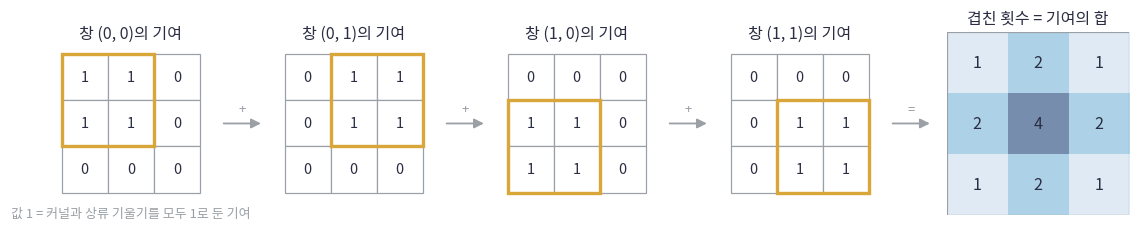

In [15]:
plot_overlap_count(count_parts, count_positions, (2, 2), count_grid)

🔍 **확인** · 왼쪽 네 판은 창 자리마다 돌려주는 기여이고, 오른쪽은 그 합입니다. 모서리 칸은 창 하나, 변의 칸은 두 개, 가운데 칸은 네 개에 들어가 4를 받습니다.
`=`로 덮어쓰면 마지막 창의 1만 남습니다. 아래 구현의 `+=`가 이 덧셈이고, 검산에서 실제 backward 출력이 이 격자와 같은지 봅니다.

📎 검사에서는 임의의 상류 배열 $G$를 정하고 스칼라 $L=\sum Y\odot G$를 만듭니다. 이때 $dL/dY=G$이므로 backward가 반환한 dX·dK·db를 같은 스칼라의 중심차분과 비교할 수 있습니다.

> **코드**
>
> - `numerical_gradient(scalar, array)`: 인자 없는 함수 `scalar()`의 값을, `array`의 원소를 하나씩 ±ε 흔들며 중심차분으로 미분합니다(01번 3절). `array`와 같은 모양의 배열을 돌려줍니다.
> - `rel_error(a, b)`: 두 배열의 상대오차. $10^{-6}$ 아래면 같은 값으로 봅니다.
> - `for value, grad in zip((X, K, b), analytic)`: 원본 배열과 그 기울기를 짝지어 모양이 같은지 확인합니다.

In [16]:
def conv_backward(dY, cache):
    """합성곱 backward: G = dY를 행으로 편 뒤 dK = Gᵀ P, db = Σ_rows G, dP = G K_flat, 그리고 dP를 창 자리마다 입력에 **더해** dX.
    dY: (N, F, oh, ow), cache: conv_forward의 것 → (dX: (N, C, H, W), dK: (F, C, kh, kw), db: (F,))."""
    shape, K, P, stride, padding = cache
    N, C, H, W = shape
    F, _, kh, kw = K.shape
    _, _, oh, ow = dY.shape
    G = dY.transpose(0, 2, 3, 1).reshape(N * oh * ow, F)                     # (N·oh·ow, F): 상류 기울기를 행으로
    dK = (G.T @ P).reshape(K.shape)                                           # dK_flat = Gᵀ P → (F, C, kh, kw). 모든 자리의 패치 × 오차의 합
    db = G.sum(axis=0)                                                        # (F,): 자리 축의 합
    dpatches = (G @ K.reshape(F, -1)).reshape(N, oh, ow, C, kh, kw)          # dP = G K_flat → 자리마다 창 모양의 기울기
    dXp = np.zeros((N, C, H + 2 * padding, W + 2 * padding))                 # 0을 두른 입력과 같은 모양
    for i in range(oh):
        for j in range(ow):
            dXp[:, :, i * stride:i * stride + kh, j * stride:j * stride + kw] += dpatches[:, i, j]   # 겹친 칸은 더함 (=가 아니라 +=)
    dX = dXp[:, :, padding:padding + H, padding:padding + W]                 # 두른 0 자리를 잘라 냄
    return dX, dK, db

In [17]:
def check_conv_backward(candidate):
    """두 설정(stride 1·padding 0, stride 2·padding 1)에서 dX·dK·db를 중심차분과 대조합니다. → {"s1p0/X", …}: 상대오차."""
    # 쓰는 것: conv_forward (2절)
    rng = np.random.default_rng(51)
    errors = {}
    for stride, padding in [(1, 0), (2, 1)]:
        X = rng.normal(size=(1, 2, 4, 5))                  # (N, C, H, W)
        K = rng.normal(size=(2, 2, 2, 3))                  # (F, C, kh, kw)
        b = rng.normal(size=2)
        Y, cache = conv_forward(X, K, b, stride, padding)
        G = rng.normal(size=Y.shape)                       # 임의의 상류 기울기
        dX, dK, db = candidate(G, cache)
        analytic = (dX, dK, db)
        for value, grad in zip((X, K, b), analytic):
            assert np.shape(grad) == value.shape, f"기울기 모양 {np.shape(grad)}은 원본 {value.shape}과 같아야 합니다"

        def scalar():
            """검사기용: 스칼라 L = Σ Y ⊙ G. 인자 없이 이번 설정의 X, K, b, G를 씁니다."""
            return float(np.sum(conv_forward(X, K, b, stride, padding)[0] * G))

        for name, array, grad in zip(["X", "K", "b"], [X, K, b], analytic):
            numeric = numerical_gradient(scalar, array)    # array를 흔들어 잰 중심차분
            error = rel_error(grad, numeric)
            assert np.isfinite(error), f"{name}의 상대오차가 유한해야 합니다"
            assert error < 2e-6, f"{name}의 상대오차 {error:.2e}는 2e−6 아래여야 합니다"
            errors[f"s{stride}p{padding}/{name}"] = error
    return errors

In [18]:
# 쓰는 것: conv_forward (2절) · count_grid (3절 겹침 셀)
conv_errors = check_conv_backward(conv_backward)
print("convolution 전체 미분 최대 상대오차:", max(conv_errors.values()))
ones_X = np.ones((1, 1, 3, 3))                                    # 입력·커널·상류 기울기를 모두 1로
ones_K = np.ones((1, 1, 2, 2))
ones_Y, ones_cache = conv_forward(ones_X, ones_K, np.zeros(1))
coverage, _, _ = conv_backward(np.ones_like(ones_Y), ones_cache)  # dX = 각 칸이 몇 개의 창에 들어갔는지
np.testing.assert_allclose(coverage[0, 0], [[1, 2, 1], [2, 4, 2], [1, 2, 1]])   # 검산: 모서리 1, 변 2, 가운데 4
np.testing.assert_allclose(coverage[0, 0], count_grid)            # 검산: 위 그림의 겹친 횟수 격자와 같음
print("겹친 패치의 기울기 누적 횟수:\n", coverage[0, 0])

convolution 전체 미분 최대 상대오차: 5.484114245342819e-10
겹친 패치의 기울기 누적 횟수:
 [[1. 2. 1.]
 [2. 4. 2.]
 [1. 2. 1.]]


🔍 **확인** · 중앙 픽셀은 네 패치에 등장하여 네 경로의 기울기를 받습니다. 이 숫자는 실제 backward의 출력이며 위 그림의 격자와 같습니다.
stride 1·padding 0과 stride 2·padding 1 두 설정에서 dX·dK·db 모두 중심차분과의 상대오차가 $2\times10^{-6}$ 아래입니다.

## 🔑 4. 풀링: 구역마다 값 하나만 남겨 크기를 줄입니다

**이 절에서 가져갈 것:** 2×2 풀링은 겹치지 않는 2×2 구역마다 평균 또는 최댓값 하나를 남깁니다. 평균은 기울기를 넷으로 나누어 네 칸에 돌려주고, 최대는 최댓값이 나온 칸 하나에 전부 보냅니다.

7의 특성 맵 26×26에서 획의 위치가 한두 칸 흔들려도 "윗획이 있다"는 사실은 같습니다. 구역마다 대표값 하나만 남기면 크기가 절반이 되고, 작은 흔들림에 덜 민감해집니다.

> **용어** · **풀링(pooling)**: 파라미터 없이 구역을 값 하나로 줄이는 연산. **평균 pooling**은 구역의 평균, **최대 pooling**은 구역의 최댓값. 코드에서는 `reshape(N, C, H//2, 2, W//2, 2)`로 구역 안쪽 축을 만든 뒤 그 축에서 `mean`·`max`.

$$Y^{mean}_{i,j}=\frac{1}{4}\sum_{u=0}^{1}\sum_{v=0}^{1}X_{2i+u,\,2j+v},\qquad
Y^{max}_{i,j}=\max_{u,v\in\{0,1\}}X_{2i+u,\,2j+v}.$$

출력 $(i,j)$는 입력에서 왼쪽 위가 $(2i, 2j)$인 2×2 구역의 평균 또는 최댓값입니다.

2×2 **평균 pooling**은 네 값을 더해 4로 나누므로 각 입력 미분도 $dY/4$입니다. **최대 pooling**은 최댓값을 만든 입력 하나로 기울기를 보냅니다. 동률에서는 미분이 유일하지 않으며, 아래 구현은 펼친 순서의 첫 최대 위치를 택합니다. 수치미분 검사는 동률을 피합니다.

여기서는 창 크기=stride=2, padding=0이고 입력 높이·너비가 짝수인 경우만 구현합니다. 일반 stride와 겹치는 pooling은 이 노트북의 범위 밖입니다. `reshape(N,C,H//2,2,W//2,2)`에서 축 3·5가 각 창의 내부 위치입니다.

> **코드**
>
> - `X.reshape(N, C, H//2, 2, W//2, 2).transpose(0, 1, 2, 4, 3, 5)`: 세로 축을 (구역 행, 안쪽 행), 가로 축을 (구역 열, 안쪽 열)로 쪼갠 뒤 안쪽 두 축을 뒤로 모읍니다. 마지막 두 축이 2×2 구역 하나입니다.
> - `.max(axis=(2, 3))`: 두 축을 한꺼번에 없애며 최댓값. `flat.argmax(axis=-1)`: 마지막 축(구역 안 4칸)에서 최댓값의 번호.
> - `dY[..., None]`: `...`은 "앞 축 전부", `None`은 새 축. `(N, C, H/2, W/2)`를 `(N, C, H/2, W/2, 1)`로 만들어 4칸에 브로드캐스팅합니다.
> - `np.arange(4) == indices[..., None]`: 구역마다 최댓값 번호 자리만 True인 `(…, 4)` 마스크. 곱하면 그 칸에만 기울기가 갑니다.
> - `np.repeat(a, 4, axis=-1)`: 마지막 축을 4번 복제. 평균 pooling은 넷에 같은 값 dY/4를 돌려줍니다.

In [19]:
# 쓰는 것: mnist_feature (1절 7 특성 맵 셀)
pool_demo = np.array([[1., 3., 2., 0.],
                      [4., 2., 1., 5.],
                      [0., 1., 3., 2.],
                      [2., 2., 1., 4.]])                            # (4, 4): 손계산용
pool_regions = pool_demo.reshape(2, 2, 2, 2).transpose(0, 2, 1, 3)  # (2, 2, 2, 2): [구역 행, 구역 열, 안쪽 행, 안쪽 열]
pool_max_demo = pool_regions.max(axis=(2, 3))                       # (2, 2): 구역마다 최댓값
pool_mean_demo = pool_regions.mean(axis=(2, 3))                     # (2, 2): 구역마다 평균
pool_argmax = []                                                    # 구역마다 최댓값이 있는 원래 칸 (그림용)
for a in range(2):
    for b in range(2):
        u, v = np.unravel_index(pool_regions[a, b].argmax(), (2, 2))   # 구역 안에서의 (행, 열)
        pool_argmax.append((2 * a + u, 2 * b + v))                  # 원래 4×4에서의 칸
mnist_pooled = mnist_feature.reshape(13, 2, 13, 2).max(axis=(1, 3))  # (13, 13): 7의 특성 맵을 2×2 최대 pooling
print("최대\n", pool_max_demo, "\n평균\n", pool_mean_demo, "\n최댓값 자리", pool_argmax)

최대
 [[4. 5.]
 [2. 4.]] 
평균
 [[2.5  2.  ]
 [1.25 2.5 ]] 
최댓값 자리 [(np.int64(1), np.int64(0)), (np.int64(1), np.int64(3)), (np.int64(3), np.int64(0)), (np.int64(3), np.int64(3))]


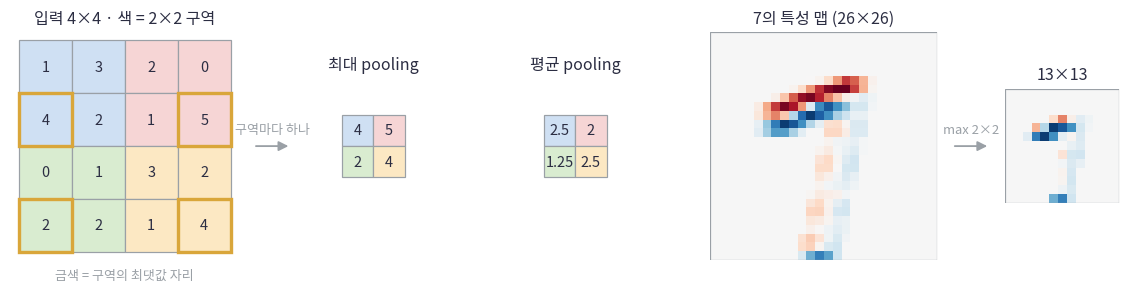

In [20]:
plot_pooling(pool_demo, pool_argmax, pool_max_demo, pool_mean_demo, mnist_feature, mnist_pooled)

🔍 **확인** · 왼쪽 4×4의 같은 색이 한 구역입니다. 금색 테두리는 그 구역의 최댓값 자리이고, 최대 pooling의 2×2에는 그 값만 남습니다. 평균 pooling은 넷의 평균이라 값이 더 부드럽습니다.
오른쪽은 7의 가로 경계 특성 맵을 2×2 최대 pooling한 것입니다. 26×26이 13×13이 되었지만 윗획의 위치는 그대로 읽힙니다.
backward에서 최대 pooling은 금색 칸에만 기울기를 보내고, 평균 pooling은 네 칸에 1/4씩 나눕니다.

In [21]:
def pool_forward(X, mode="mean"):
    """2×2 pooling forward (창 = stride = 2). 구역마다 평균 또는 최댓값 하나.
    X: (N, C, H, W), H·W 짝수 → (Y: (N, C, H/2, W/2), cache: (X.shape, mode, 최댓값 번호 또는 None))."""
    N, C, H, W = X.shape
    assert H % 2 == 0, "높이가 짝수여야 2×2 구역으로 나뉩니다"
    assert W % 2 == 0, "너비가 짝수여야 2×2 구역으로 나뉩니다"
    assert mode in ("mean", "max"), "mode는 mean 또는 max"
    windows = X.reshape(N, C, H // 2, 2, W // 2, 2).transpose(0, 1, 2, 4, 3, 5)   # (N, C, H/2, W/2, 2, 2): 마지막 두 축이 구역
    flat = windows.reshape(N, C, H // 2, W // 2, 4)                             # 구역의 4칸을 한 축으로
    if mode == "mean":
        Y, indices = flat.mean(axis=-1), None
    else:
        indices = flat.argmax(axis=-1)                    # (N, C, H/2, W/2): 구역마다 최댓값 번호 0–3 (backward용)
        Y = flat.max(axis=-1)
    return Y, (X.shape, mode, indices)


def pool_backward(dY, cache):
    """2×2 pooling backward. 평균: 네 칸에 dY/4씩. 최대: 최댓값이 있던 칸 하나에 dY 전부.
    dY: (N, C, H/2, W/2), cache: pool_forward의 것 → dX: (N, C, H, W)."""
    shape, mode, indices = cache
    N, C, H, W = shape
    if mode == "mean":
        dflat = np.repeat(dY[..., None] / 4, 4, axis=-1)                        # (…, 4): 넷에 1/4씩
    else:
        mask = np.arange(4) == indices[..., None]                               # (…, 4): 최댓값 자리만 True
        dflat = dY[..., None] * mask                                            # 그 자리에만 dY
    return dflat.reshape(N, C, H // 2, W // 2, 2, 2).transpose(0, 1, 2, 4, 3, 5).reshape(shape)   # forward의 모양 바꾸기를 거꾸로

In [22]:
# 쓰는 것: rng (2절 검산 셀) · pool_demo, pool_max_demo, pool_mean_demo (4절 손계산 셀)
pool_X = rng.normal(size=(1, 2, 4, 4))
for mode in ["mean", "max"]:
    Yp, cp = pool_forward(pool_X, mode)
    upstream = rng.normal(size=Yp.shape)                    # 임의의 상류 기울기 G

    def pool_scalar():
        """검사기용: 스칼라 L = Σ Y ⊙ G (이번 mode의 pooling)."""
        return float(np.sum(pool_forward(pool_X, mode)[0] * upstream))

    numeric = numerical_gradient(pool_scalar, pool_X)       # pool_X를 흔들어 잰 중심차분
    error = rel_error(pool_backward(upstream, cp), numeric)
    assert error < 2e-6, f"{mode} pooling backward의 상대오차가 2e−6 아래여야 합니다"
    print(mode, "backward 상대오차", error)
hand_pool = np.array([[[[1., 2.], [3., 4.]]]])              # (1, 1, 2, 2): 구역 하나짜리 손계산
np.testing.assert_allclose(pool_forward(hand_pool)[0], 2.5)                            # 검산: 평균 (1+2+3+4)/4
max_Y, max_cache = pool_forward(hand_pool, "max")
np.testing.assert_allclose(pool_backward(np.ones_like(max_Y), max_cache), [[[[0, 0], [0, 1]]]])   # 검산: 최대 4가 있던 칸에만 기울기
np.testing.assert_allclose(pool_forward(pool_demo[None, None], "max")[0][0, 0], pool_max_demo)     # 검산: 위 그림의 최대 pooling
np.testing.assert_allclose(pool_forward(pool_demo[None, None], "mean")[0][0, 0], pool_mean_demo)   # 검산: 위 그림의 평균 pooling

mean backward 상대오차 1.8890476578625065e-10
max backward 상대오차 4.15233628616863e-10


🔍 **확인** · 평균·최대 pooling 모두 backward가 중심차분과 맞고, 손계산한 2×2 예제(평균 2.5, 최대의 기울기는 4가 있던 칸 하나)도 맞습니다. 위 그림의 4×4 결과도 같은 함수가 냅니다.
pooling은 정보를 버립니다. 작은 이동에 덜 민감해질 수 있지만, **모든 이동에 대한 완전한 불변성을 보장하지 않습니다.** stride·경계·뒤의 flatten 층에 따라 이동 효과가 달라집니다.

## 🔑 5. 작은 완성 모델: 숫자 도안 → 합성곱 → 분류

**이 절에서 가져갈 것:** 합성곱·ReLU·풀링·펼침·선형층을 차례로 이어 logit 10개를 내고, 02번의 softmax CE와 04번의 Adam으로 학습합니다. backward는 같은 순서를 거꾸로 밟으며 각 층의 backward를 부릅니다.

입력은 8×8에 그린 0–9 도안입니다. 원본 모양을 직접 적고 위치와 잡음을 무작위로 바꿉니다. 학습 500장, 검증 200장은 별도 난수로 생성합니다. 검증 집합은 가중치 갱신에 쓰지 않습니다. 두 집합이 같은 10개 도안 생성 규칙을 공유하므로 결과는 **그 규칙 안의 새 위치·잡음에 대한 성능**입니다. 실제 손글씨나 MNIST 성능으로 읽지 마세요.

> **용어**
>
> - **펼침(flatten)**: $(N, 6, 3, 3)$을 $(N, 54)$로 펴서 03번의 선형층에 넣는 것. 코드에서는 `pooled.reshape(len(X), -1)`.
> - **logit**: softmax 전의 점수 10개. 02번에서 softmax CE의 입력이었습니다.

모델의 shape 흐름:
`(N,1,8,8) → conv 3×3 → (N,6,6,6) → ReLU → mean pool → (N,6,3,3) → flatten 54 → logits 10`.

아래 도식은 이 흐름을 블록으로 그린 것이고, 파라미터 수는 본문에서 셉니다.

> **코드**
>
> - `"111/101/101/101/111"`: 도안 한 장을 문자열로. `p.split("/")`로 5행으로 자르고, 행의 글자 `"1"`·`"0"`을 `int`로 바꿔 5×3 배열을 만듭니다(중첩 컴프리헨션).
> - `rng.shuffle(y)`: 배열의 순서를 제자리에서 섞습니다. `np.clip(a, 0, 1)`: 0보다 작으면 0, 1보다 크면 1로 자릅니다.
> - `p = {"K": …, "c": …, "W": …, "b": …}`: 파라미터를 이름으로 찾는 사전. `grads`도 같은 키로 만들어 `for key in p`로 함께 갱신합니다.
> - `* (Z > 0)`: True/False 배열을 곱해 ReLU의 도함수(양수 자리만 1)를 적용합니다(03번 5절).

In [23]:
cnn_blocks = [("입력", "(N, 1, 8, 8)"), ("conv 3×3, 커널 6개", "(N, 6, 6, 6)"), ("ReLU", "(N, 6, 6, 6)"),
              ("mean pool 2×2", "(N, 6, 3, 3)"), ("펼침", "(N, 54)"), ("선형 54→10", "(N, 10) logit"), ("softmax CE", "손실 1개")]   # 도식용 (이름, 모양)
n_conv = 6 * (1 * 3 * 3) + 6                                       # 커널 6개 × 9 + 편향 6
n_linear = 54 * 10 + 10                                            # 선형층 W (54, 10) + b (10,)
n_fc_alternative = (8 * 8 + 1) * 54                                # 같은 54차원을 완전 연결로 만들 때
print("파라미터 수: conv", n_conv, "+ 선형", n_linear, "=", n_conv + n_linear, "· 완전 연결로 54차원을 만들면", n_fc_alternative)

파라미터 수: conv 60 + 선형 550 = 610 · 완전 연결로 54차원을 만들면 3510


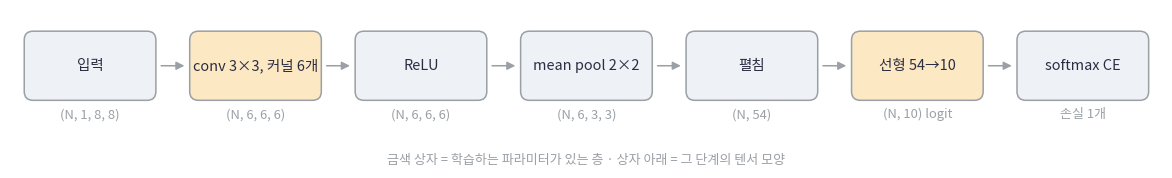

In [24]:
plot_cnn_blocks(cnn_blocks)

🔍 **확인** · 왼쪽에서 오른쪽으로 텐서 모양이 $(N,1,8,8)$에서 $(N,10)$으로 바뀝니다. 파라미터가 있는 상자는 conv(60개)와 선형층(550개)뿐이고, ReLU·풀링·펼침은 파라미터 없이 값이나 모양만 바꿉니다.
같은 54차원 표현을 완전 연결로 만들면 3,510개가 필요합니다. backward는 이 화살표를 거꾸로 따라가며 각 층의 backward를 부릅니다.

In [25]:
def make_digits(n, seed):
    """8×8 숫자 도안 n장. 0–9의 5×3 도안을 무작위 위치에 놓고 잡음(표준편차 0.06)을 더합니다.
    n: 장수, seed: 시드 → (X: (n, 1, 8, 8) 0–1 실수, y: (n,) 정답 0–9)."""
    patterns = ["111/101/101/101/111", "010/110/010/010/111", "111/001/111/100/111",
                "111/001/111/001/111", "101/101/111/001/001", "111/100/111/001/111",
                "111/100/111/101/111", "111/001/001/010/010", "111/101/111/101/111",
                "111/101/111/001/111"]                                             # 숫자 0–9의 도안 (행을 /로 구분)
    templates = np.array([[[int(v) for v in row] for row in p.split("/")] for p in patterns])   # (10, 5, 3): 0/1 배열
    rng = np.random.default_rng(seed)
    y = np.arange(n) % 10                                    # (n,): 0…9를 고르게
    rng.shuffle(y)
    X = np.zeros((n, 1, 8, 8))
    for i, label in enumerate(y):
        top, left = rng.integers(0, 4), rng.integers(0, 6)   # 도안을 놓을 왼쪽 위 (5×3이 8×8 안에 들어가는 범위)
        X[i, 0, top:top + 5, left:left + 3] = templates[label]
    X = np.clip(X + rng.normal(0, 0.06, X.shape), 0, 1)     # 잡음을 더하고 0–1로 자름
    return X, y

In [26]:
def ce_loss(logits, y):
    """softmax cross-entropy 평균과 logit 기울기 (02번 8절): J = −mean log P[n, y_n], dZ = (P − T)/N.
    logits: (N, 10), y: (N,) 정수 → (J: 숫자, dZ: (N, 10))."""
    shifted = logits - logits.max(axis=1, keepdims=True)                 # 행마다 최댓값을 빼 지수가 넘치지 않게
    logp = shifted - np.log(np.exp(shifted).sum(axis=1, keepdims=True))  # (N, 10): log softmax
    loss = -logp[np.arange(len(y)), y].mean()                            # 정답 자리의 −log를 평균
    dlogits = np.exp(logp)                                               # (N, 10): P
    dlogits[np.arange(len(y)), y] -= 1                                   # 정답 자리만 1을 빼면 P − T
    return loss, dlogits / len(y)

In [27]:
def cnn_forward(X, p):
    """모델 forward: conv → ReLU → mean pool → 펼침 → 선형층. X: (N, 1, 8, 8), p: 파라미터 사전 → (logits: (N, 10), cache)."""
    # 쓰는 것: conv_forward (2절) · pool_forward (4절)
    Z, conv_cache = conv_forward(X, p["K"], p["c"])         # (N, 6, 6, 6)
    A = np.maximum(Z, 0)                                    # ReLU
    pooled, pool_cache = pool_forward(A)                    # (N, 6, 3, 3): 평균 pooling
    flat = pooled.reshape(len(X), -1)                       # (N, 54): 펼침
    logits = flat @ p["W"] + p["b"]                         # (N, 10): 선형층
    return logits, (Z, conv_cache, pool_cache, flat, pooled.shape)

In [28]:
def cnn_backward(dlogits, cache, p):
    """모델 backward: forward의 순서를 거꾸로. 선형층 → 펼침 되돌리기 → pool backward → ReLU 도함수 → conv backward.
    dlogits: (N, 10), cache: cnn_forward의 것, p: 파라미터 사전 → (dX: (N, 1, 8, 8), grads: p와 같은 키의 사전)."""
    # 쓰는 것: conv_backward (3절) · pool_backward (4절)
    Z, conv_cache, pool_cache, flat, pooled_shape = cache
    dW, db = flat.T @ dlogits, dlogits.sum(axis=0)          # 선형층 (03번 5절의 두 식)
    dpool = (dlogits @ p["W"].T).reshape(pooled_shape)      # (N, 6, 3, 3): 펼침을 되돌린 기울기
    dZ = pool_backward(dpool, pool_cache) * (Z > 0)         # (N, 6, 6, 6): pool backward 뒤 ReLU 도함수를 곱함
    dX, dK, dc = conv_backward(dZ, conv_cache)
    return dX, {"K": dK, "c": dc, "W": dW, "b": db}

In [29]:
# 쓰는 것: make_digits (5절 도안 생성 셀)
X_train, y_train = make_digits(500, 501)                  # (500, 1, 8, 8), (500,): 학습용
X_valid, y_valid = make_digits(200, 502)                  # (200, 1, 8, 8), (200,): 검증용. 다른 시드
print("학습:", X_train.shape, "검증:", X_valid.shape)

학습: (500, 1, 8, 8) 검증: (200, 1, 8, 8)


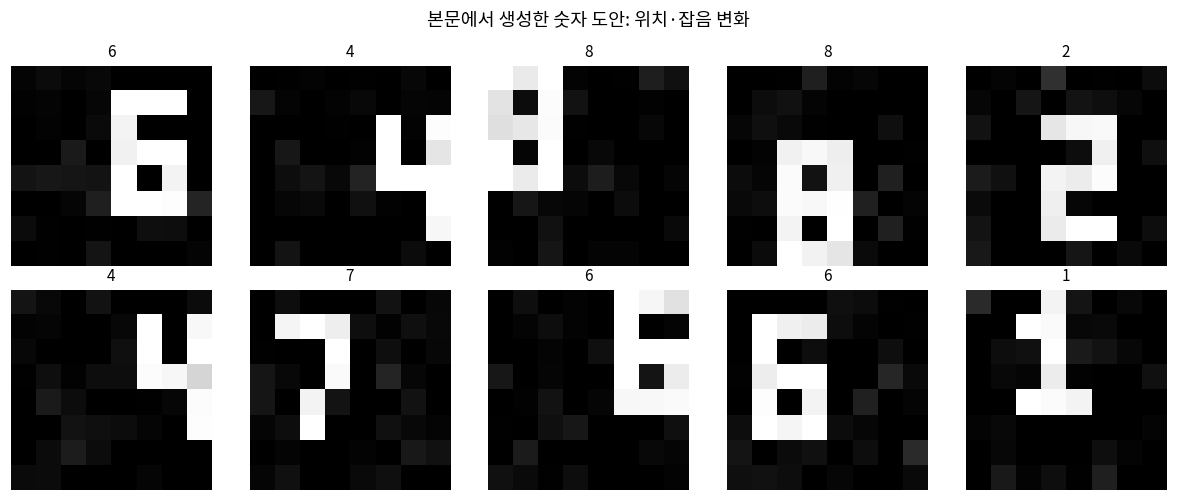

In [30]:
plot_images(X_train[:10, 0], y_train[:10], title="본문에서 생성한 숫자 도안: 위치·잡음 변화")

🔍 **확인** · 같은 숫자라도 위치와 잡음이 다릅니다. 커널을 모든 자리에서 공유하므로 도안이 어디에 있든 같은 획 검출기가 반응합니다.

📎 CE와 Adam은 02·04의 계산을 여기에도 적습니다. `p`와 `grads`는 같은 이름을 가진 배열의 사전입니다. `state`에는 파라미터별 1차·2차 이동평균을 저장합니다. 모든 기울기를 **같은 갱신 전 파라미터**에서 구한 다음 함께 갱신합니다.

먼저 모델 전체의 파라미터와 입력 미분도 검사합니다. ReLU는 0에서 꺾이므로 이 검사에서는 꺾임에서 떨어진 입력을 사용합니다. 학습 성능이 올라가는 것만으로 미분 구현이 맞다고 판단하지 않습니다.

In [31]:
def adam_update(p, grads, state, step, lr=0.02):
    """Adam 갱신 (04번 6절)을 파라미터 사전의 모든 배열에. p를 제자리에서 바꾸고 state의 (m, v)를 갱신합니다.
    p, grads: 같은 키의 사전, state: 키 → (m, v), step: 1부터 세는 스텝 수."""
    for key in p:                                                     # "K", "c", "W", "b" 차례로
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]                                # 1차 모멘트
        v = 0.999 * v + 0.001 * grads[key] ** 2                       # 2차 모멘트
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)   # 편향 보정 뒤 갱신
        state[key] = (m, v)


def init_cnn(seed=503):
    """파라미터 사전: 커널 6개(He 초기화 √(2/9)), 선형층 (54, 10)(표준편차 √(1/54)), 편향 0."""
    rng = np.random.default_rng(seed)
    return {"K": rng.normal(size=(6, 1, 3, 3)) * np.sqrt(2 / 9), "c": np.zeros(6),
            "W": rng.normal(size=(54, 10)) * np.sqrt(1 / 54), "b": np.zeros(10)}

In [32]:
# 쓰는 것: rng (2절 검산 셀) · cnn_forward, cnn_backward (5절)
probe_X = rng.normal(size=(1, 1, 8, 8))                   # (1, 1, 8, 8): 검사 입력 (ReLU의 꺾이는 0에서 떨어진 난수)
probe_p = init_cnn(504)
probe_logits, probe_cache = cnn_forward(probe_X, probe_p)
probe_G = rng.normal(size=probe_logits.shape)             # (1, 10): 임의의 상류 기울기
probe_dX, probe_grads = cnn_backward(probe_G, probe_cache, probe_p)


def probe_scalar():
    """검사기용: 스칼라 L = Σ logits ⊙ G."""
    return float(np.sum(cnn_forward(probe_X, probe_p)[0] * probe_G))


cnn_errors = {key: rel_error(probe_grads[key], numerical_gradient(probe_scalar, value)) for key, value in probe_p.items()}   # 파라미터마다 상대오차
cnn_errors["X"] = rel_error(probe_dX, numerical_gradient(probe_scalar, probe_X))
assert max(cnn_errors.values()) < 2e-6, "모든 기울기의 상대오차가 2e−6 아래여야 합니다"
print("CNN 합성 전체 미분 최대 상대오차:", max(cnn_errors.values()))

CNN 합성 전체 미분 최대 상대오차: 8.04833810323961e-10


🔍 **확인** · 커널·편향·선형층·입력 모두 상대오차가 $2\times10^{-6}$ 아래입니다. 이제 학습합니다. 50장 미니배치를 600스텝 돌리고, 50스텝마다 학습·검증 CE를 같은 파라미터로 잽니다.

> **코드**
>
> - `{key: (np.zeros_like(value), np.zeros_like(value)) for key, value in p.items()}`: 파라미터마다 Adam 상태 (m, v)를 0으로 만든 사전.
> - `rng_train.choice(len(X_train), 50, replace=False)`: 0…499 중 50개를 겹치지 않게 뽑은 번호. 이번 스텝의 미니배치입니다.

In [33]:
# 쓰는 것: X_train, y_train, X_valid, y_valid (5절 데이터 셀) · cnn_forward, cnn_backward, ce_loss, adam_update, init_cnn (5절)
p = init_cnn()
state = {key: (np.zeros_like(value), np.zeros_like(value)) for key, value in p.items()}   # Adam 상태 (m, v)
rng_train = np.random.default_rng(505)
history = {"step": [], "train": [], "valid": []}
for step in range(601):
    if step % 50 == 0:                                       # 1. 50스텝마다 같은 파라미터로 학습·검증 CE 기록
        train_logits, _ = cnn_forward(X_train, p)
        valid_logits, _ = cnn_forward(X_valid, p)
        history["step"].append(step)
        history["train"].append(ce_loss(train_logits, y_train)[0])
        history["valid"].append(ce_loss(valid_logits, y_valid)[0])
    if step == 600:
        break
    batch = rng_train.choice(len(X_train), 50, replace=False)   # 2. 미니배치 50장
    logits, cache = cnn_forward(X_train[batch], p)           # 3. forward → 손실 → backward
    loss, dlogits = ce_loss(logits, y_train[batch])
    _, grads = cnn_backward(dlogits, cache, p)
    adam_update(p, grads, state, step + 1)                   # 4. 갱신 (t는 1부터)
valid_predictions = valid_logits.argmax(axis=1)              # (200,): 마지막 기록 시점의 검증 예측
valid_accuracy = np.mean(valid_predictions == y_valid)
print(f"학습 CE {history['train'][0]:.6f} → {history['train'][-1]:.6f}")
print(f"검증 CE {history['valid'][-1]:.6f} · 정확도 {valid_accuracy:.1%} (n={len(y_valid)})")
assert history["train"][-1] < history["train"][0] * 0.4, "학습 CE가 처음의 40% 아래로 내려가야 합니다"
assert valid_accuracy > 0.8, "검증 정확도가 80%를 넘어야 합니다"

학습 CE 2.345114 → 0.087676
검증 CE 0.229319 · 정확도 93.5% (n=200)


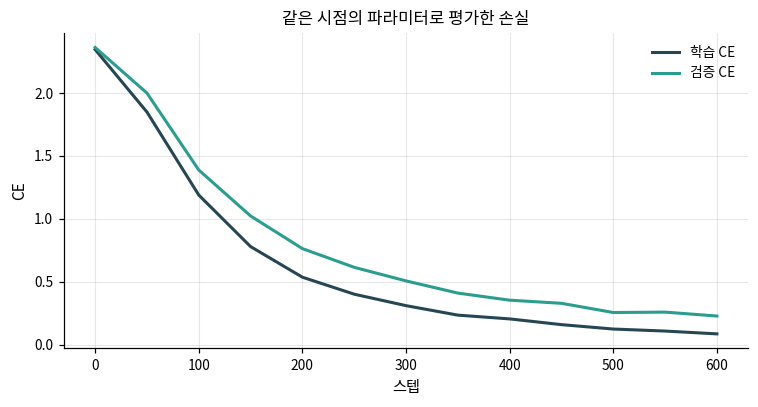

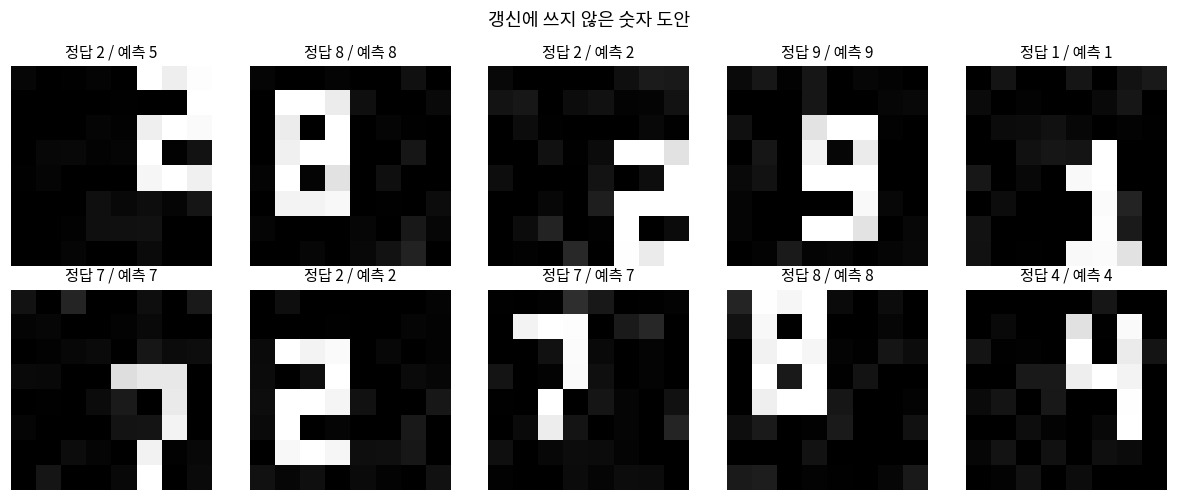

In [34]:
plot_curves(history["step"], {"학습 CE": history["train"], "검증 CE": history["valid"]},
            title="같은 시점의 파라미터로 평가한 손실", ylabel="CE")
plot_images(X_valid[:10, 0], [f"정답 {a} / 예측 {b}" for a, b in zip(y_valid[:10], valid_predictions[:10])],
            title="갱신에 쓰지 않은 숫자 도안")

🔍 **확인** · 학습 CE가 처음의 40% 아래로 내려가고 검증 정확도가 80%를 넘습니다. 검증 CE가 학습 CE보다 조금 높은 것은 새 위치·잡음이라 그렇습니다.
아래 도안 10장은 갱신에 쓰지 않은 검증 데이터이며, 제목의 정답과 예측을 비교하세요. 틀린 것이 있다면 어느 도안끼리 닮았는지 보세요.

## 🔍 6. 공유는 이동에 대한 어떤 성질을 줍니까?

> **용어**
>
> - **등변성(equivariance)**: 입력을 옮기면 출력도 같은 만큼 옮겨지는 성질. stride 1 합성곱이 가집니다.
> - **불변성(invariance)**: 입력을 옮겨도 출력이 그대로인 성질. 이 노트북의 분류기 전체가 가진다고 주장할 수 없습니다.

stride=1인 convolution에 주기적 경계(`np.roll`)를 함께 적용하면 입력 이동과 출력 이동이 대응합니다. 아래에서는 경계 영향을 없애기 위해 `padding='wrap'`에 해당하는 입력을 본문에서 만들고 valid convolution을 적용합니다. 일반적인 **0 padding 경계에서는 같은 등식이 그대로 성립하지 않습니다.**

이는 출력도 같이 움직이는 **equivariance**입니다. 출력 자체가 같아지는 **invariance**와 구분합니다. 뒤에 flatten+위치별 가중치를 붙인 이 분류기 전체에 이동 불변성을 주장할 수는 없습니다.

> **코드**
>
> - `np.pad(X, …, mode="wrap")`: 0 대신 반대쪽 끝의 값으로 두릅니다. 오른쪽 끝 다음이 왼쪽 끝인 주기적 경계입니다.
> - `np.roll(X, 1, axis=3)`: 가로 축으로 한 칸 굴립니다. 맨 오른쪽 열이 맨 왼쪽으로 돌아옵니다.

In [35]:
def periodic_conv(X, K):
    """주기적 경계로 1칸 두른 뒤 valid 합성곱. X: (N, C, H, W), K: (F, C, 3, 3) → (N, F, H, W) (편향 0)."""
    # 쓰는 것: conv_forward (2절)
    wrapped = np.pad(X, ((0, 0), (0, 0), (1, 1), (1, 1)), mode="wrap")   # 반대쪽 끝의 값으로 두름
    return conv_forward(wrapped, K, np.zeros(len(K)))[0]

In [36]:
# 쓰는 것: rng (2절 검산 셀)
shift_X = rng.normal(size=(1, 1, 5, 5))
shift_K = rng.normal(size=(2, 1, 3, 3))
base = periodic_conv(shift_X, shift_K)                            # 합성곱한 뒤
moved = periodic_conv(np.roll(shift_X, 1, axis=3), shift_K)       # 입력을 한 칸 굴린 뒤 합성곱
np.testing.assert_allclose(moved, np.roll(base, 1, axis=3), atol=1e-12)   # 검산: 출력도 정확히 한 칸 굴러감 (등변성)
print("주기적 경계 + stride 1의 이동 대응 검산 통과")

주기적 경계 + stride 1의 이동 대응 검산 통과


🔍 **확인** · 입력을 오른쪽으로 한 칸 굴린 뒤 합성곱한 결과가, 합성곱한 뒤 한 칸 굴린 결과와 $10^{-12}$ 안에서 같습니다. 커널이 자리마다 같기 때문입니다.

## ✏️ 7. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 출력 크기 (1절)

입력 $H\times W$, 커널 $k_h\times k_w$, stride, padding에서 출력 높이·너비를 돌려주는 두 줄을 채우세요.

In [37]:
def exercise_output_size(H, W, kh, kw, stride=1, padding=0):
    """연습 A: 합성곱 출력 크기. H, W: 입력, kh, kw: 커널, stride, padding: 정수 → (oh, ow)."""
    assert stride >= 1, "stride는 1 이상이어야 합니다"
    assert padding >= 0, "padding은 0 이상이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: oh, ow = 1절의 출력 높이·너비 공식 (내림 나눗셈 //)
    ### 힌트: oh = (H + 2 * padding - kh) // stride + 1, ow도 같은 꼴
    raise NotImplementedError
    return oh, ow

In [38]:
def check_output_size(candidate):
    """1절 격자·5절 도안·손계산 한 경우와 conv_forward의 실제 모양으로 검사합니다."""
    # 쓰는 것: check_X, check_K, check_b, conv_forward (2절 검산 셀)
    assert candidate(5, 5, 3, 3) == (3, 3), "5×5에 3×3 커널이면 (3, 3)이어야 합니다 (1절 격자)"
    assert candidate(8, 8, 3, 3) == (6, 6), "8×8에 3×3 커널이면 (6, 6)이어야 합니다 (5절 도안)"
    assert candidate(4, 5, 2, 3, stride=2, padding=1) == (3, 3), "손계산: (4+2−2)//2+1 = 3, (5+2−3)//2+1 = 3"
    assert candidate(4, 5, 2, 3, 2, 1) == conv_forward(check_X, check_K, check_b, 2, 1)[0].shape[2:], "conv_forward의 실제 출력 모양과 같아야 합니다"
    print("출력 크기: 공식과 conv_forward의 실제 모양이 일치합니다.")

run_check(check_output_size, exercise_output_size, hint="oh = (H + 2 * padding - kh) // stride + 1; ow = (W + 2 * padding - kw) // stride + 1")

☐ exercise_output_size: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: oh = (H + 2 * padding - kh) // stride + 1; ow = (W + 2 * padding - kw) // stride + 1


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
oh = (H + 2 * padding - kh) // stride + 1
ow = (W + 2 * padding - kw) // stride + 1
```

</details>

### ✏️ 연습 B · 패치 행렬곱 (2절)

패치 행렬 `P`, 커널 `K` $(F, C, k_h, k_w)$, 편향 `b`에서 $Y_{rows}=PK_{flat}^\top+b$ 한 줄을 채우세요.

In [39]:
def exercise_conv_rows(P, K, b):
    """연습 B: 패치 행렬곱 Y_rows = P K_flatᵀ + b. P: (N·oh·ow, C·kh·kw), K: (F, C, kh, kw), b: (F,) → (N·oh·ow, F)."""
    F = K.shape[0]
    assert P.shape[1] == K[0].size, "P의 열 수는 커널 하나의 원소 수 C·kh·kw여야 합니다"
    assert b.shape == (F,), "편향은 커널 수만큼 (F,)이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: rows = P @ (K를 (F, C·kh·kw)로 펼친 것의 전치) + b   (모양 (N·oh·ow, F))
    ### 힌트: K.reshape(F, -1).T
    raise NotImplementedError
    return rows

In [40]:
def check_conv_rows(candidate):
    """2절 손계산 격자와 conv_forward가 캐시에 남긴 P로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: patch_P, patch_rows (2절 패치 셀) · grid_K (📎 데이터 셀) · check_X, check_K, check_b, conv_forward (2절 검산 셀)
    np.testing.assert_allclose(candidate(patch_P, grid_K[None, None], np.zeros(1))[:, 0], patch_rows)   # 검산: 2절 손계산
    Y_ref, cache_ref = conv_forward(check_X, check_K, check_b, 2, 1)
    rows = candidate(cache_ref[2], check_K, check_b)                                                      # 캐시에 남긴 P
    np.testing.assert_allclose(rows.reshape(2, 3, 3, 3).transpose(0, 3, 1, 2), Y_ref)                     # 검산: 접으면 conv_forward의 Y
    print("패치 행렬곱: 2절 손계산·conv_forward와 일치합니다.")

run_check(check_conv_rows, exercise_conv_rows, hint="rows = P @ K.reshape(F, -1).T + b")

☐ exercise_conv_rows: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: rows = P @ K.reshape(F, -1).T + b


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
rows = P @ K.reshape(F, -1).T + b
```

</details>

### ✏️ 연습 C · 겹친 자리에 더하기 (3절)

패치 모양의 기울기 `dpatches` $(N, H_o, W_o, C, k_h, k_w)$를 입력 모양으로 되돌립니다. 반복문은 써 두었으니 창에 **더하는** 한 줄을 채우세요.

In [41]:
def exercise_accumulate(dpatches, shape, kh, kw, stride, padding):
    """연습 C: 패치 모양의 기울기를 입력 모양으로 되돌리며 겹친 칸에 더합니다. dpatches: (N, oh, ow, C, kh, kw) → dX: shape = (N, C, H, W)."""
    N, C, H, W = shape
    _, oh, ow = dpatches.shape[:3]
    dXp = np.zeros((N, C, H + 2 * padding, W + 2 * padding))    # 0을 두른 입력 모양
    for i in range(oh):
        for j in range(ow):
            ### 이 주석 아래에 다음을 구현하세요.
            ### 구현할 내용: 자리 (i, j)의 패치 기울기 dpatches[:, i, j] (모양 (N, C, kh, kw))를 dXp의 그 창에 더합니다.
            ### 힌트: 3절 conv_backward의 += 한 줄. 창은 i*stride:i*stride+kh, j*stride:j*stride+kw
            raise NotImplementedError
    return dXp[:, :, padding:padding + H, padding:padding + W]

In [42]:
def check_accumulate(candidate):
    """3절의 겹침 격자와 conv_backward의 dX로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: count_grid (3절 겹침 셀) · check_X, check_K, check_b, conv_forward (2절 검산 셀) · conv_backward (3절)
    ones_parts = np.ones((1, 2, 2, 1, 2, 2))                                        # 3×3 입력, 2×2 창 네 자리, 기여 모두 1
    np.testing.assert_allclose(candidate(ones_parts, (1, 1, 3, 3), 2, 2, 1, 0)[0, 0], count_grid)   # 검산: 3절 격자
    Y_c, cache_c = conv_forward(check_X, check_K, check_b, 2, 1)
    G_c = np.random.default_rng(3).normal(size=Y_c.shape)
    dX_ref = conv_backward(G_c, cache_c)[0]                                         # 본문 backward의 dX
    G_rows = G_c.transpose(0, 2, 3, 1).reshape(-1, 3)                               # 3절과 같은 방법으로 dpatches를 만듦
    dpatches_c = (G_rows @ check_K.reshape(3, -1)).reshape(2, 3, 3, 2, 2, 3)
    np.testing.assert_allclose(candidate(dpatches_c, check_X.shape, 2, 3, 2, 1), dX_ref)   # 검산: conv_backward와 같음
    print("겹침 누적: 3절 격자·conv_backward와 일치합니다.")

run_check(check_accumulate, exercise_accumulate, hint="dXp[:, :, i * stride:i * stride + kh, j * stride:j * stride + kw] += dpatches[:, i, j]")

☐ exercise_accumulate: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dXp[:, :, i * stride:i * stride + kh, j * stride:j * stride + kw] += dpatches[:, i, j]


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dXp[:, :, i * stride:i * stride + kh, j * stride:j * stride + kw] += dpatches[:, i, j]
```

</details>

### ✏️ 연습 D · 평균 pooling의 backward (4절)

상류 기울기 `dY` $(N, C, H/2, W/2)$를 네 칸에 $1/4$씩 나누어 돌려줍니다. 구역을 원래 모양으로 되돌리는 줄은 써 두었으니 나누어 복제하는 한 줄을 채우세요.

In [43]:
def exercise_mean_pool_backward(dY, cache):
    """연습 D: 평균 pooling backward. dY: (N, C, H/2, W/2), cache: pool_forward의 것 → dX: (N, C, H, W)."""
    shape, mode, indices = cache
    N, C, H, W = shape
    assert mode == "mean", "이 연습은 평균 pooling만 다룹니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dflat = dY를 4로 나눈 값을 마지막에 새 축으로 4번 복제한 배열 (모양 (N, C, H//2, W//2, 4))
    ### 힌트: np.repeat(dY[..., None] / 4, 4, axis=-1)
    raise NotImplementedError
    return dflat.reshape(N, C, H // 2, W // 2, 2, 2).transpose(0, 1, 2, 4, 3, 5).reshape(shape)

In [44]:
def check_mean_pool_backward(candidate):
    """중심차분과 손계산(넷에 1/4씩)으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: pool_forward (4절) · hand_pool (4절 검산 셀)
    rng_check = np.random.default_rng(57)
    X_c = rng_check.normal(size=(2, 3, 4, 6))
    Y_c, cache_c = pool_forward(X_c, "mean")
    G_c = rng_check.normal(size=Y_c.shape)

    def mean_pool_scalar():
        """검사기용: 스칼라 L = Σ Y ⊙ G."""
        return float(np.sum(pool_forward(X_c)[0] * G_c))

    numeric_c = numerical_gradient(mean_pool_scalar, X_c)
    np.testing.assert_allclose(candidate(G_c, cache_c), numeric_c, atol=1e-8, rtol=1e-6)               # 검산: 중심차분
    np.testing.assert_allclose(candidate(np.ones((1, 1, 1, 1)), pool_forward(hand_pool, "mean")[1]), np.full((1, 1, 2, 2), 0.25))   # 검산: 손계산. 넷에 1/4씩
    print("평균 pooling backward: 중심차분·손계산(넷에 1/4씩)과 일치합니다.")

run_check(check_mean_pool_backward, exercise_mean_pool_backward, hint="dflat = np.repeat(dY[..., None] / 4, 4, axis=-1)")

☐ exercise_mean_pool_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dflat = np.repeat(dY[..., None] / 4, 4, axis=-1)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dflat = np.repeat(dY[..., None] / 4, 4, axis=-1)
```

</details>

### 🔍 완성 예제 · 커널 수 바꾸기

커널을 6개에서 3개로 줄이면 conv 출력이 $(N,3,6,6)$, 풀링 뒤 $(N,3,3,3)$, 펼침이 27차원이 되어 선형층은 $(27, 10)$이어야 합니다. 초기화의 두 shape만 바뀌고 forward·backward 식은 같습니다. 학습 전에 전체 미분을 검산합니다.

In [45]:
def init_cnn_filters(filters, seed=503):
    """커널 수를 바꾼 파라미터 사전. 펼침 차원이 filters × 9로 바뀌므로 선형층 W의 행 수도 함께 바뀝니다."""
    rng_v = np.random.default_rng(seed)
    return {"K": rng_v.normal(size=(filters, 1, 3, 3)) * np.sqrt(2 / 9), "c": np.zeros(filters),
            "W": rng_v.normal(size=(filters * 9, 10)) * np.sqrt(1 / (filters * 9)), "b": np.zeros(10)}

In [46]:
# 쓰는 것: probe_X (5절 검산 셀) · cnn_forward, cnn_backward (5절)
variant_p = init_cnn_filters(3)
variant_logits, variant_cache = cnn_forward(probe_X, variant_p)
variant_G = np.random.default_rng(506).normal(size=variant_logits.shape)
variant_dX, variant_grads = cnn_backward(variant_G, variant_cache, variant_p)


def variant_scalar():
    """검사기용: 스칼라 L = Σ logits ⊙ G (커널 3개 모델)."""
    return float(np.sum(cnn_forward(probe_X, variant_p)[0] * variant_G))


variant_errors = {key: rel_error(variant_grads[key], numerical_gradient(variant_scalar, value)) for key, value in variant_p.items()}
assert variant_cache[3].shape == (1, 27), "커널 3개면 펼침이 3 × 3 × 3 = 27차원이어야 합니다"
assert max(variant_errors.values()) < 2e-6, "구조를 바꿔도 모든 기울기의 상대오차가 2e−6 아래여야 합니다"
print("커널 3개: 펼침 차원", variant_cache[3].shape[1], "· 파라미터", sum(v.size for v in variant_p.values()), "· 최대 상대오차", max(variant_errors.values()))

커널 3개: 펼침 차원 27 · 파라미터 310 · 최대 상대오차 3.5507944523548476e-10


### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** convolution에서 무엇이 지역적이고 무엇이 공유되는지 설명할 수 있나요? → 1절
- **수식:** padding·stride를 포함해 출력 shape와 한 출력의 합을 쓸 수 있나요? → 1절
- **구현:** 패치 펼침의 축 순서, dK의 위치 합, dX의 겹침 누적을 직접 쓸 수 있나요? → 2·3절
- **변형:** 채널·커널·stride를 바꿔도 수치미분을 통과시키고, equivariance와 invariance를 구분할 수 있나요? → 5·6절

다음은 [06 RNN](06_rnn.ipynb)입니다. 이미지의 **위치**에 공유한 가중치를 시간의 **단계**에 공유해 봅니다.

📎 [LeCun 등, 1998](https://bottou.org/papers/lecun-98h)은 지역 수용 영역과 가중치 공유를 사용한 문서 인식 CNN의 원전입니다. 이 노트북의 작은 도안 데이터와 모델은 설명을 위해 새로 구성한 예제이며 LeNet의 재현 실험은 아닙니다.